In [1]:
from python_model.bpsk.dsp import tx  
import matplotlib.pyplot as plt
import numpy as np

[INFO] dsp.py:118: Header:[0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1]
[INFO] dsp.py:119: Version:[0, 0, 0, 1]
Length:[0, 0, 0, 0, 1, 1, 0, 0]
[INFO] dsp.py:120: Flags:[1, 0]
packetID:[0, 0, 0, 0, 0, 0, 0, 1]
[INFO] dsp.py:124: [-1, -1, -1, 1, -1, -1, -1, -1, 1, 1, -1, -1, 1, -1, -1, -1, -1, -1, -1, -1, -1, 1]


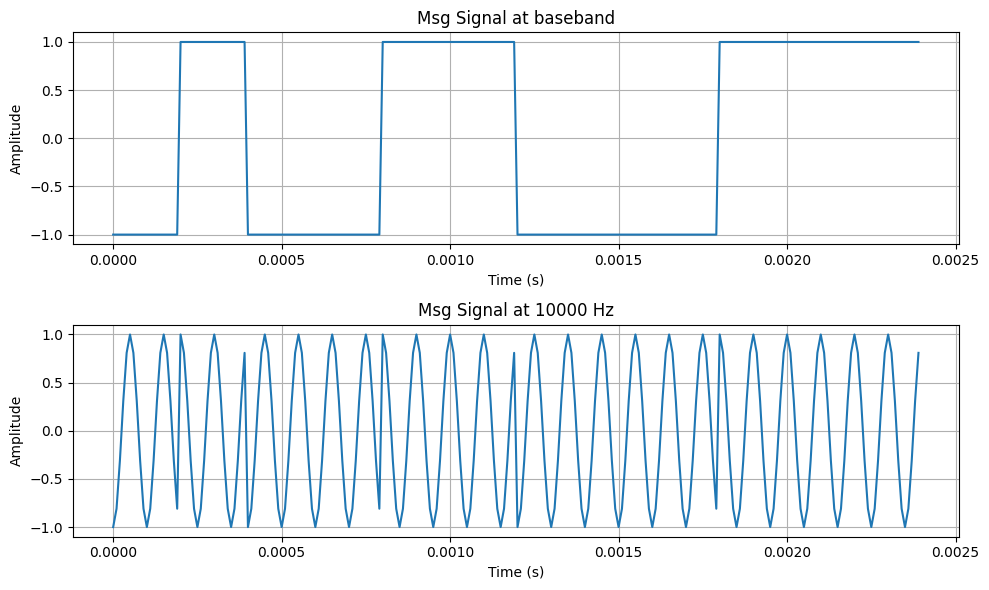

In [2]:
wave = tx('13',5,20,10000,100000)
msg = '010011000111'
(header,baseband_header) = wave.generate_header(1,len(msg),2,1)  
(passband,baseband,time) = wave.packetize(msg,baseband_header)    
wave.bpsk_modulation(msg,True)


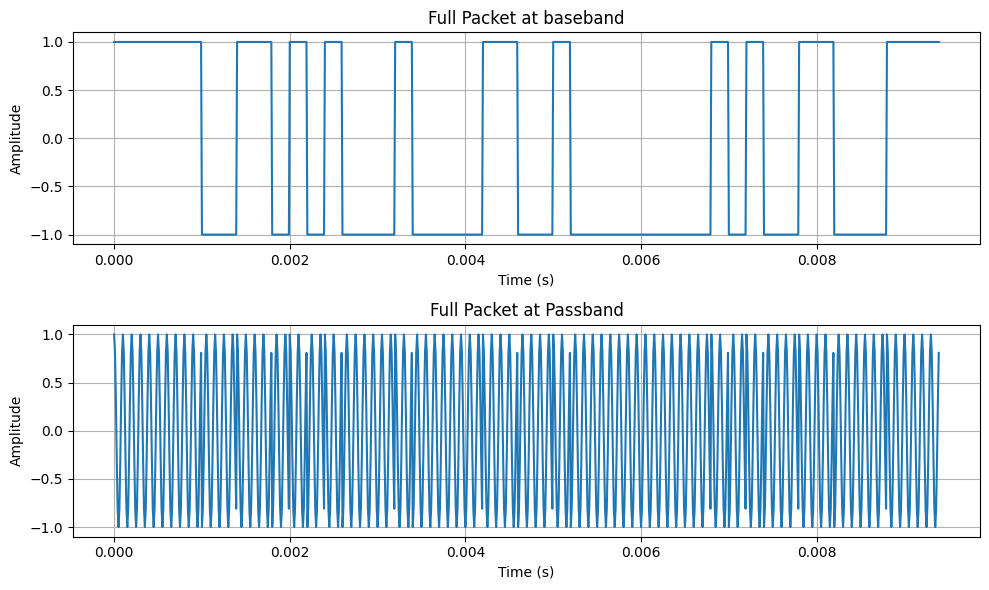

In [3]:
fig,ax = plt.subplots(nrows=2,ncols=1,figsize=(10,6))

ax[0].plot(time,baseband)
ax[1].plot(time,np.real(passband))

ax[0].set_title(f"Full Packet at baseband")
ax[0].set_xlabel('Time (s)')
ax[0].set_ylabel('Amplitude')
ax[0].grid(True)

ax[1].set_title(f"Full Packet at Passband")
ax[1].set_xlabel('Time (s)')
ax[1].set_ylabel('Amplitude')
ax[1].grid(True)
plt.tight_layout()
plt.show()

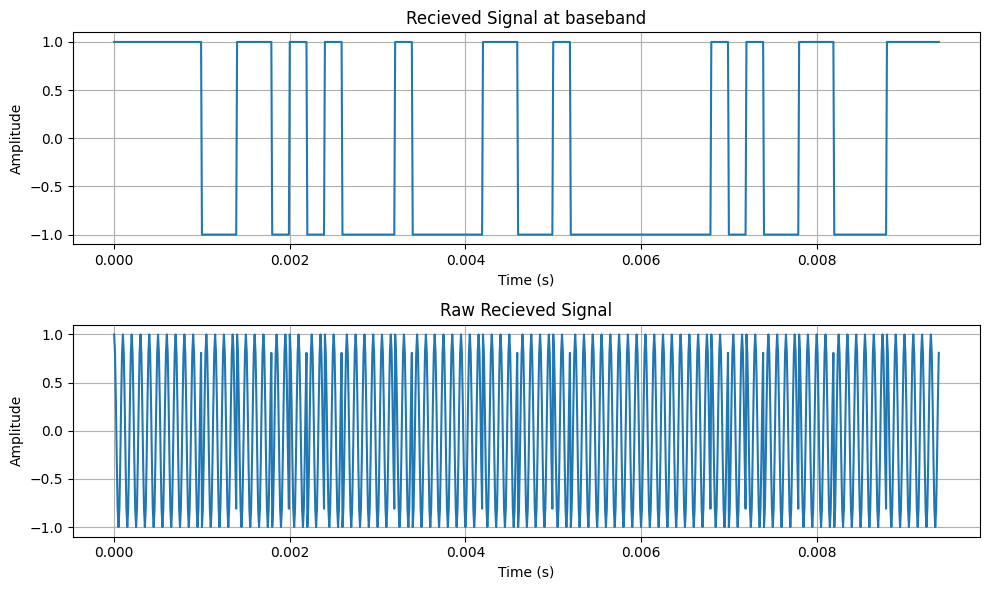

In [ ]:
#Simulate signal in a given amount of time
gateLen = 5000 #samples

#creating Gaussian nosie
rng = np.random.default_rng()
noise = rng.norma(locals)

raw_noise = np.random.random(gateLen)+1j*np.random.random(gateLen)
rx_signal = passband



#Need to DDC signal
#We must multiple out the carrier frequecy using the conjugate of the carrier
msg_time = np.arange(0,len(passband))/wave.sampleRate
DDC = passband * np.exp(-1j*2*np.pi*wave.carrier_frequency*msg_time)

#This should be at baseband now.
fig,ax = plt.subplots(nrows=2,ncols=1,figsize=(10,6))

ax[0].plot(msg_time,np.real(DDC))
ax[0].set_title(f"Recieved Signal at baseband")
ax[0].set_xlabel('Time (s)')
ax[0].set_ylabel('Amplitude')
ax[0].grid(True)


ax[1].plot(msg_time,np.real(passband))
ax[1].set_title(f"Raw Recieved Signal")
ax[1].set_xlabel('Time (s)')
ax[1].set_ylabel('Amplitude')
ax[1].grid(True)
plt.tight_layout()
plt.show()